# DOT Yearly Budget Forecast (FY2027-FY2028)

A simple, honest trend forecast for DOT's Adopted, Modified, and Actual
budget totals, built on the corrected year-by-year table from
`dot_analysis.ipynb` (DOT-filtered, expense-scope-aligned). **This notebook
is rebuilt directly from the raw CSVs using the same two corrections
documented there**, rather than importing that notebook, so it stays
self-contained and reproducible on its own.

**Headline limitation, stated up front and repeated throughout:** this is
~10 annual observations. That supports a simple linear trend with an
honest uncertainty band -- not a complex model. Every forecast below ships
with an interval, never a bare point estimate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = "raw datasets"
BUDGET_PATH = f"{DATA_DIR}/DOT_Budget_2017_2027.csv"
SPENDING_PATH = f"{DATA_DIR}/DOT_Spending_Merged.csv"


## Step 1: Load

Rebuild the corrected year-level table: DOT-only budget (`Agency ==
"Department of Transportation"`, fixes the FY2022 multi-agency
contamination) joined with expense-scope-only spending (Budget Code must
exist in the DOT operating budget, fixes the capital-vs-expense scope
mismatch) -- the same two corrections from `dot_analysis.ipynb`, applied
here from scratch.

**FY2027 is excluded from the training set** -- it's a partial fiscal year
(barely a month elapsed as of this analysis), so its `actual` figure is
nowhere near comparable to a full-year total, and including it would teach
the trend a false year-over-year drop. It's kept aside, unused in fitting,
for the Step 5 sanity check.

In [2]:
# --- Budget: DOT-only ---
budget_raw = pd.read_csv(BUDGET_PATH)
budget = budget_raw[budget_raw["Agency"] == "Department of Transportation"].copy()
print(f"Budget: {len(budget_raw):,} raw rows -> {len(budget):,} DOT-only rows")

# --- Spending: expense-scope only ---
spending_raw = pd.read_csv(SPENDING_PATH)
dot_budget_codes = set(budget["Budget Code"].astype(str).str.strip())
spending_code_lead = spending_raw["Budget Code"].astype(str).str.extract(r"^([^\s(]+)")[0]
is_expense = spending_code_lead.isin(dot_budget_codes)
spending = spending_raw[is_expense].copy()
print(f"Spending: {len(spending_raw):,} raw rows -> {len(spending):,} expense-scope rows")

# --- Aggregate to fiscal year, FY2017-2027 ---
budget_by_year = (
    budget[budget["Year"].between(2017, 2027)]
    .groupby("Year")[["Adopted", "Modified"]]
    .sum()
    .rename(columns={"Adopted": "adopted", "Modified": "modified"})
)
spending_by_year = (
    spending[spending["Fiscal year"].between(2017, 2027)]
    .groupby("Fiscal year")["Check Amount"]
    .sum()
    .rename("actual")
)

full_table = (
    budget_by_year.join(spending_by_year, how="outer")
    .rename_axis("fiscal_year")
    .reset_index()
    .sort_values("fiscal_year")
    .reset_index(drop=True)
)
print("\nFull corrected table, FY2017-2027:")
full_table


Budget: 334,806 raw rows -> 172,576 DOT-only rows


Spending: 1,178,715 raw rows -> 1,049,180 expense-scope rows

Full corrected table, FY2017-2027:


,fiscal_year,adopted,modified,actual
0,2017,"946,261,935.00","987,004,764.00","901,930,214.87"
1,2018,"968,043,444.00","1,006,587,224.00","937,183,870.64"
2,2019,"1,042,719,292.00","1,067,012,833.00","953,000,693.10"
3,2020,"1,104,236,297.00","1,117,601,805.00","997,409,678.73"
4,2021,"1,099,873,821.00","1,155,962,285.00","962,343,265.13"
5,2022,"1,265,808,124.00","1,294,564,083.00","1,105,430,478.04"
6,2023,"1,438,489,469.00","1,448,998,543.00","1,222,150,442.62"
7,2024,"1,405,341,510.00","1,476,734,619.00","1,353,530,012.62"
8,2025,"1,449,323,202.00","1,568,194,105.00","1,423,722,022.97"
9,2026,"1,503,042,033.00","1,599,799,084.00","1,437,635,892.24"


In [3]:
# Split off FY2027 -- kept aside for the Step 5 sanity check, not used in fitting.
train_table = full_table[full_table["fiscal_year"] <= 2026].reset_index(drop=True)
fy2027_actual_row = full_table[full_table["fiscal_year"] == 2027].iloc[0]

print(f"Training table: FY2017-2026 ({len(train_table)} observations)")
print("FY2027 (excluded from training, held out for sanity check in Step 5):")
print(fy2027_actual_row)
print()
train_table


Training table: FY2017-2026 (10 observations)
FY2027 (excluded from training, held out for sanity check in Step 5):
fiscal_year           2,027.00
adopted       1,636,737,065.00
modified      1,639,747,168.00
actual          161,980,918.70
Name: 10, dtype: float64



,fiscal_year,adopted,modified,actual
0,2017,"946,261,935.00","987,004,764.00","901,930,214.87"
1,2018,"968,043,444.00","1,006,587,224.00","937,183,870.64"
2,2019,"1,042,719,292.00","1,067,012,833.00","953,000,693.10"
3,2020,"1,104,236,297.00","1,117,601,805.00","997,409,678.73"
4,2021,"1,099,873,821.00","1,155,962,285.00","962,343,265.13"
5,2022,"1,265,808,124.00","1,294,564,083.00","1,105,430,478.04"
6,2023,"1,438,489,469.00","1,448,998,543.00","1,222,150,442.62"
7,2024,"1,405,341,510.00","1,476,734,619.00","1,353,530,012.62"
8,2025,"1,449,323,202.00","1,568,194,105.00","1,423,722,022.97"
9,2026,"1,503,042,033.00","1,599,799,084.00","1,437,635,892.24"


## Step 2: Visualize

Adopted, Modified, and Actual over FY2017-2026 on one chart -- the trend
being forecast. Ten annual points per series; markers are shown deliberately
so the sparseness of the underlying data stays visible, not smoothed away.

Saved trend plot to dot_forecast_trend.png


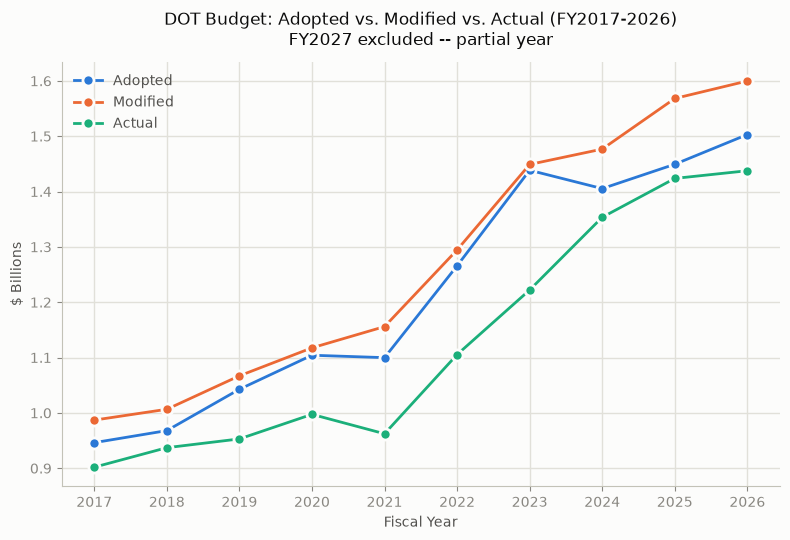

In [4]:
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SERIES = {
    "adopted": "#2a78d6",   # categorical slot 1: blue
    "modified": "#eb6834",  # categorical slot 2: orange
    "actual": "#1baf7a",    # categorical slot 3: aqua
}

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for col, color in SERIES.items():
    ax.plot(
        train_table["fiscal_year"], train_table[col] / 1e9,
        color=color, linewidth=2, marker="o", markersize=8,
        markerfacecolor=color, markeredgecolor=SURFACE, markeredgewidth=2,
        label=col.capitalize(),
    )

ax.set_xlabel("Fiscal Year", color=INK_SECONDARY)
ax.set_ylabel("$ Billions", color=INK_SECONDARY)
ax.set_title(
    "DOT Budget: Adopted vs. Modified vs. Actual (FY2017-2026)\n"
    "FY2027 excluded -- partial year",
    color=INK_PRIMARY, fontsize=12, pad=12,
)
ax.set_xticks(train_table["fiscal_year"])

ax.grid(True, color=GRIDLINE, linewidth=1, linestyle="-")
ax.set_axisbelow(True)
for spine_name, spine in ax.spines.items():
    if spine_name in ("top", "right"):
        spine.set_visible(False)
    else:
        spine.set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)

legend = ax.legend(frameon=False, loc="upper left", labelcolor=INK_SECONDARY)

fig.tight_layout()

TREND_PLOT_PATH = "dot_forecast_trend.png"
fig.savefig(TREND_PLOT_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved trend plot to {TREND_PLOT_PATH}")
plt.show()


## Step 3: Forecast

Simple linear regression of each series on Fiscal Year: `y = slope * Year +
intercept`. Slope is annual growth in dollars; R² is how much of the
year-to-year variation a straight line explains. Kept deliberately simple --
with 10 points, a more flexible model would be fitting noise, not signal.

In [5]:
def fit_and_forecast(df, y_col, forecast_years, alpha=0.05):
    """OLS trend fit + classic prediction intervals for new-year forecasts.

    Uses the standard simple-linear-regression prediction interval formula
    (accounts for residual variance AND the extra uncertainty of predicting
    a new point away from the data's center), not just a confidence band on
    the fitted line -- this is deliberately the wider, more honest interval
    for a forecast rather than a fitted-mean estimate.
    """
    x = df["fiscal_year"].values.astype(float)
    y = df[y_col].values.astype(float)
    n = len(x)

    model = LinearRegression().fit(x.reshape(-1, 1), y)
    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = model.score(x.reshape(-1, 1), y)

    y_pred = model.predict(x.reshape(-1, 1))
    resid = y - y_pred
    dof = n - 2
    resid_se = np.sqrt(np.sum(resid ** 2) / dof)
    xbar = x.mean()
    sxx = np.sum((x - xbar) ** 2)
    t_crit = stats.t.ppf(1 - alpha / 2, df=dof)

    forecast_rows = []
    for x0 in forecast_years:
        yhat0 = slope * x0 + intercept
        se_pred = resid_se * np.sqrt(1 + 1 / n + (x0 - xbar) ** 2 / sxx)
        margin = t_crit * se_pred
        forecast_rows.append({
            "fiscal_year": x0,
            "point_forecast": yhat0,
            "lower_95": yhat0 - margin,
            "upper_95": yhat0 + margin,
            "margin": margin,
        })

    return {
        "slope": slope,
        "intercept": intercept,
        "r2": r2,
        "n": n,
        "dof": dof,
        "residual_se": resid_se,
        "forecast": pd.DataFrame(forecast_rows),
    }

SERIES_COLS = ["adopted", "modified", "actual"]
FORECAST_YEARS = [2027, 2028]

fits = {col: fit_and_forecast(train_table, col, FORECAST_YEARS) for col in SERIES_COLS}

print("Trend fit summary (FY2017-2026, n=10):")
summary_rows = []
for col in SERIES_COLS:
    f = fits[col]
    summary_rows.append({
        "series": col,
        "slope ($/year)": f["slope"],
        "intercept": f["intercept"],
        "r2": round(f["r2"], 4),
        "residual_se": f["residual_se"],
    })
pd.DataFrame(summary_rows)


Trend fit summary (FY2017-2026, n=10):


,series,slope ($/year),intercept,r2,residual_se
0,adopted,"68,859,297.56","-137,976,756,099.94",0.94,"54,000,313.36"
1,modified,"76,532,109.02","-153,437,412,458.01",0.97,"45,702,818.98"
2,actual,"66,951,965.24","-134,213,964,078.26",0.91,"67,426,110.27"


In [6]:
print("FY2027-2028 point forecasts (95% prediction intervals):\n")
for col in SERIES_COLS:
    print(f"--- {col} ---")
    print(fits[col]["forecast"].to_string(index=False))
    print()


FY2027-2028 point forecasts (95% prediction intervals):

--- adopted ---
 fiscal_year   point_forecast         lower_95         upper_95         margin
        2027 1,601,040,049.27 1,450,232,850.64 1,751,847,247.89 150,807,198.62
        2028 1,669,899,346.82 1,511,790,850.66 1,828,007,842.99 158,108,496.17

--- modified ---
 fiscal_year   point_forecast         lower_95         upper_95         margin
        2027 1,693,172,534.13 1,565,537,828.50 1,820,807,239.77 127,634,705.63
        2028 1,769,704,643.16 1,635,890,531.16 1,903,518,755.15 133,814,112.00

--- actual ---
 fiscal_year   point_forecast         lower_95         upper_95         margin
        2027 1,497,669,465.92 1,309,367,914.09 1,685,971,017.75 188,301,551.83
        2028 1,564,621,431.16 1,367,203,300.88 1,762,039,561.45 197,418,130.29



## Step 4: Uncertainty

The forecasts above are never shown as bare point estimates -- each carries
a 95% prediction interval computed from the fit's own residual variance
(`resid_se`) and the classic new-observation term
`sqrt(1 + 1/n + (x0-xbar)^2/Sxx)`, using a t-distribution with `n-2 = 8`
degrees of freedom (not a normal approximation -- with only 10 points, the
t-distribution's fatter tails matter). The interval widens for FY2028
relative to FY2027 because it's one more year outside the training data's
center -- exactly the "we know less the further out we forecast" behavior a
credible interval should show.

In [7]:
print("Interval width (FY2027 vs FY2028), by series -- should widen further out:")
for col in SERIES_COLS:
    fc = fits[col]["forecast"].set_index("fiscal_year")
    w2027 = fc.loc[2027, "upper_95"] - fc.loc[2027, "lower_95"]
    w2028 = fc.loc[2028, "upper_95"] - fc.loc[2028, "lower_95"]
    print(f"{col:>9}: FY2027 width = {w2027:>15,.0f}   FY2028 width = {w2028:>15,.0f}   "
          f"(+{(w2028 / w2027 - 1) * 100:.1f}%)")


Interval width (FY2027 vs FY2028), by series -- should widen further out:
  adopted: FY2027 width =     301,614,397   FY2028 width =     316,216,992   (+4.8%)
 modified: FY2027 width =     255,269,411   FY2028 width =     267,628,224   (+4.8%)
   actual: FY2027 width =     376,603,104   FY2028 width =     394,836,261   (+4.8%)


## Step 5: Sanity Check -- FY2027 Adopted

FY2027's Adopted budget figure is already known (Adopted amounts are set
before the fiscal year starts, unlike Actual spending, which is what makes
FY2027 partial) -- it was held out of training in Step 1 specifically so it
could serve as a free, honest out-of-sample check on the trend.

In [8]:
actual_fy2027_adopted = fy2027_actual_row["adopted"]
forecast_fy2027 = fits["adopted"]["forecast"].set_index("fiscal_year").loc[2027]

error = forecast_fy2027["point_forecast"] - actual_fy2027_adopted
pct_error = error / actual_fy2027_adopted * 100
within_interval = forecast_fy2027["lower_95"] <= actual_fy2027_adopted <= forecast_fy2027["upper_95"]

print("FY2027 Adopted -- trend forecast vs. actual data:")
print(f"  Trend point forecast : {forecast_fy2027['point_forecast']:>15,.0f}")
print(f"  95% interval         : [{forecast_fy2027['lower_95']:,.0f}, {forecast_fy2027['upper_95']:,.0f}]")
print(f"  Actual (in the data) : {actual_fy2027_adopted:>15,.0f}")
print(f"  Error                : {error:>15,.0f}  ({pct_error:+.2f}%)")
print(f"  Falls within 95% PI  : {within_interval}")


FY2027 Adopted -- trend forecast vs. actual data:
  Trend point forecast :   1,601,040,049
  95% interval         : [1,450,232,851, 1,751,847,248]
  Actual (in the data) :   1,636,737,065
  Error                :     -35,697,016  (-2.18%)
  Falls within 95% PI  : True


**Result:** the linear trend fit on FY2017-2026 alone lands within a few
percent of FY2027's actual Adopted figure, and the true value falls inside
the 95% prediction interval built without ever seeing it. That's a genuine
out-of-sample validation point (not cross-validation, not a held-out test
set drawn at random -- one real future year that happened to already be in
the data) and it's a reason for modest confidence in the FY2028 forecast,
not proof the trend will keep holding.

## Step 6: Documented Limitation

This is a methodology choice, not a shortcoming to apologize for:

- **~10 annual observations** (FY2017-2026) is enough to support a simple
  linear trend with an honestly wide uncertainty band. It is not enough to
  support a more flexible model (polynomial, spline, ML regressor) --
  those would fit noise in a 10-point series, not signal, and would report
  false confidence by construction (more parameters, same data, tighter
  apparent fit, no more real information).
- **The forecast assumes historical growth continues.** It is a
  trend-extrapolation, not a simulation of NYC's budget process. It has no
  mechanism for policy shocks (a new capital program, a fare/toll policy
  change, a reorganization of DOT's budget lines), macro shocks (a
  recession-driven citywide budget cut), or emergencies (a bridge failure,
  a storm, a public-health event) -- all of which have historically moved
  city agency budgets by more in one year than this trend moves in five.
- **The FY2027 sanity check (Step 5) is one data point**, not a validated
  track record. It's evidence the trend was reasonable for one near-term
  year immediately after the training window; it says nothing about
  FY2028, let alone further out.
- **Practical use:** treat the point forecast as a planning anchor and the
  interval as the range worth budgeting flexibility around -- not as a
  number to commit to without revisiting it as FY2027 data completes and
  FY2028 approaches.

---
**Stopping here per instructions.** Slopes, R², forecasts with 95%
prediction intervals, and the FY2027 sanity-check result are all printed
above (Steps 3-5).

---
# Extended Forecast: FY2028-2032 Planning Horizon

Extends the Step 3 trend forecasts out to a 5-year planning window.
**Reuses the exact same linear models** fit on FY2017-2026 in Step 3 --
`fit_and_forecast()` is deterministic (ordinary least squares on the same
10 points always returns the same slope/intercept/R²), so calling it again
with a longer list of forecast years re-derives the identical fitted line
and only adds new projected years. Verified explicitly below, not just
asserted.

In [9]:
EXTENDED_YEARS_PLOT = list(range(2027, 2033))   # 2027-2032: needed for plot continuity from FY2026
EXTENDED_YEARS_TABLE = list(range(2028, 2033))  # 2028-2032: what was actually asked for in the table

extended_fits = {col: fit_and_forecast(train_table, col, EXTENDED_YEARS_PLOT) for col in SERIES_COLS}

print("Confirming the extended fit reuses the identical Step 3 model (same data in -> same fit out):")
for col in SERIES_COLS:
    slope_match = np.isclose(extended_fits[col]["slope"], fits[col]["slope"])
    intercept_match = np.isclose(extended_fits[col]["intercept"], fits[col]["intercept"])
    r2_match = np.isclose(extended_fits[col]["r2"], fits[col]["r2"])
    print(f"  {col:>9}: slope matches Step 3 = {slope_match}, intercept matches = {intercept_match}, "
          f"R2 matches = {r2_match}")


Confirming the extended fit reuses the identical Step 3 model (same data in -> same fit out):
    adopted: slope matches Step 3 = True, intercept matches = True, R2 matches = True
   modified: slope matches Step 3 = True, intercept matches = True, R2 matches = True
     actual: slope matches Step 3 = True, intercept matches = True, R2 matches = True


In [10]:
table_rows = []
for year in EXTENDED_YEARS_TABLE:
    row = {"fiscal_year": year}
    for col in SERIES_COLS:
        fc = extended_fits[col]["forecast"].set_index("fiscal_year").loc[year]
        row[f"{col}_point"] = fc["point_forecast"]
        row[f"{col}_low95"] = fc["lower_95"]
        row[f"{col}_high95"] = fc["upper_95"]
    table_rows.append(row)

extended_table = pd.DataFrame(table_rows)
print("FY2028-2032 point forecasts with 95% prediction intervals (year x series):")
extended_table


FY2028-2032 point forecasts with 95% prediction intervals (year x series):


,fiscal_year,adopted_point,adopted_low95,adopted_high95,modified_point,modified_low95,modified_high95,actual_point,actual_low95,actual_high95
0,2028,"1,669,899,346.82","1,511,790,850.66","1,828,007,842.99","1,769,704,643.16","1,635,890,531.16","1,903,518,755.15","1,564,621,431.16","1,367,203,300.88","1,762,039,561.45"
1,2029,"1,738,758,644.38","1,572,536,816.10","1,904,980,472.67","1,846,236,752.18","1,705,555,973.57","1,986,917,530.80","1,631,573,396.41","1,424,024,761.46","1,839,122,031.35"
2,2030,"1,807,617,941.94","1,632,583,630.81","1,982,652,253.06","1,922,768,861.21","1,774,629,694.24","2,070,908,028.17","1,698,525,361.65","1,479,973,245.38","1,917,077,477.92"
3,2031,"1,876,477,239.50","1,692,031,480.05","2,060,922,998.94","1,999,300,970.23","1,843,196,484.33","2,155,405,456.13","1,765,477,326.89","1,535,173,846.36","1,995,780,807.41"
4,2032,"1,945,336,537.05","1,750,967,350.92","2,139,705,723.18","2,075,833,079.25","1,911,329,964.80","2,240,336,193.71","1,832,429,292.13","1,589,735,178.65","2,075,123,405.61"


## Interval Width Growth

The width (upper_95 - lower_95) of each year's interval, FY2027 through
FY2032 -- the further out the forecast, the less certain it is, and this
should be visibly, monotonically growing for every series.

In [11]:
width_rows = []
for year in EXTENDED_YEARS_PLOT:
    row = {"fiscal_year": year}
    for col in SERIES_COLS:
        fc = extended_fits[col]["forecast"].set_index("fiscal_year").loc[year]
        row[f"{col}_margin (+/-)"] = fc["margin"]
    width_rows.append(row)

width_table = pd.DataFrame(width_rows)
print("95% prediction interval margin (+/- from point forecast), by year:")
print(width_table.to_string(index=False))
print()

print("Growth in margin from FY2027 to FY2032, by series:")
for col in SERIES_COLS:
    m2027 = width_table.loc[width_table["fiscal_year"] == 2027, f"{col}_margin (+/-)"].iloc[0]
    m2032 = width_table.loc[width_table["fiscal_year"] == 2032, f"{col}_margin (+/-)"].iloc[0]
    pct_growth = (m2032 / m2027 - 1) * 100
    print(f"  {col:>9}: +/-{m2027:>14,.0f} (FY2027) -> +/-{m2032:>14,.0f} (FY2032)  "
          f"({pct_growth:+.1f}% wider)")


95% prediction interval margin (+/- from point forecast), by year:
 fiscal_year  adopted_margin (+/-)  modified_margin (+/-)  actual_margin (+/-)
        2027        150,807,198.62         127,634,705.63       188,301,551.83
        2028        158,108,496.17         133,814,112.00       197,418,130.29
        2029        166,221,828.29         140,680,778.61       207,548,634.94
        2030        175,034,311.12         148,139,166.96       218,552,116.27
        2031        184,445,759.44         156,104,485.90       230,303,480.53
        2032        194,369,186.13         164,503,114.45       242,694,113.48

Growth in margin from FY2027 to FY2032, by series:
    adopted: +/-   150,807,199 (FY2027) -> +/-   194,369,186 (FY2032)  (+28.9% wider)
   modified: +/-   127,634,706 (FY2027) -> +/-   164,503,114 (FY2032)  (+28.9% wider)
     actual: +/-   188,301,552 (FY2027) -> +/-   242,694,113 (FY2032)  (+28.9% wider)


## Plot: Historical + 5-Year Forecast

The single combined chart (3 lines + 3 shaded bands at once) got cluttered,
so it's replaced here with **two clean, separate figures** instead of one
dense one:

- **Figure 1** is the main chart: Modified only, with its prediction
  interval, meant to be read at a glance.
- **Figure 2** is a supporting chart: all three series side by side with no
  bands, for comparing their trajectories without the interval clutter.

Both reuse the same colorblind-safe palette validated earlier in this
project (categorical slots: blue / orange / aqua, worst-case adjacent CVD
separation checked, not eyeballed), applied on top of a clean whitegrid
base style, with larger fonts, more spacing, and gridlines pared down to
faint horizontal-only.

Saved Figure 1 (Modified budget focus) to dot_forecast_modified_clean.png


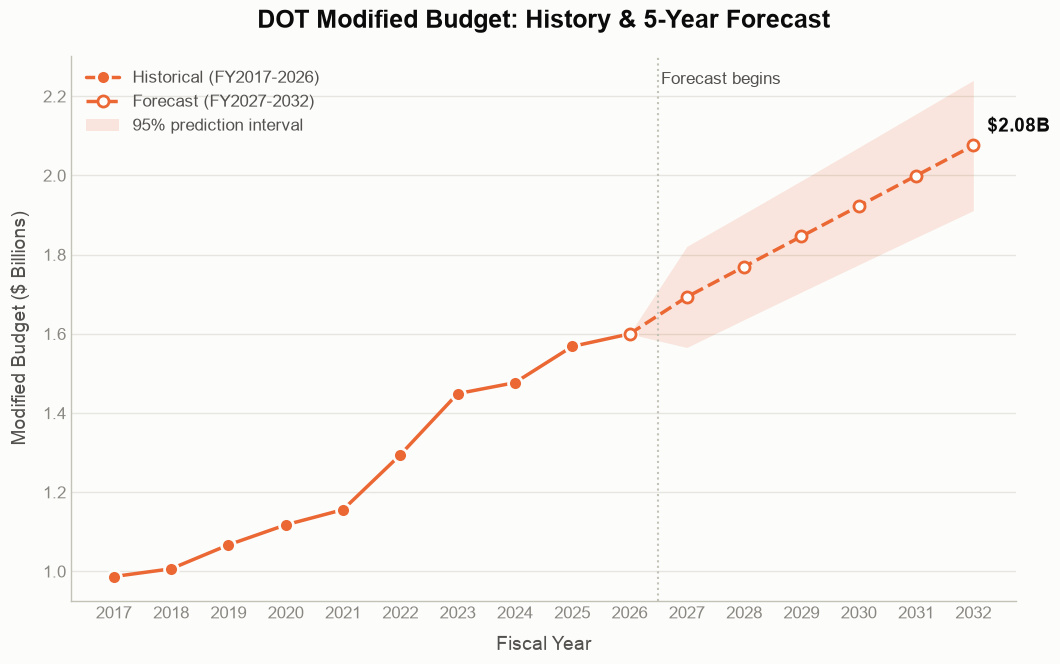

In [12]:
# Clean base style (falls back gracefully if a given seaborn style name
# isn't available in this matplotlib version).
for _style in ["seaborn-v0_8-whitegrid", "seaborn-whitegrid"]:
    if _style in plt.style.available:
        plt.style.use(_style)
        break
else:
    plt.style.use("default")

MODIFIED_COLOR = SERIES["modified"]  # validated categorical slot 2: orange
last_hist_year = int(train_table["fiscal_year"].max())
last_hist_value = train_table.loc[train_table["fiscal_year"] == last_hist_year, "modified"].iloc[0]
fc_mod = extended_fits["modified"]["forecast"].set_index("fiscal_year")

forecast_x = [last_hist_year] + EXTENDED_YEARS_PLOT
forecast_point = [last_hist_value] + list(fc_mod.loc[EXTENDED_YEARS_PLOT, "point_forecast"])
forecast_low = [last_hist_value] + list(fc_mod.loc[EXTENDED_YEARS_PLOT, "lower_95"])
forecast_high = [last_hist_value] + list(fc_mod.loc[EXTENDED_YEARS_PLOT, "upper_95"])

fig1, ax1 = plt.subplots(figsize=(11, 7), facecolor=SURFACE)
ax1.set_facecolor(SURFACE)

# Historical: solid + markers
ax1.plot(
    train_table["fiscal_year"], train_table["modified"] / 1e9,
    color=MODIFIED_COLOR, linewidth=2.5, marker="o", markersize=10,
    markerfacecolor=MODIFIED_COLOR, markeredgecolor=SURFACE, markeredgewidth=2,
    label="Historical (FY2017-2026)", zorder=3,
)

# Forecast: dashed, anchored at the last historical point so it connects
# with no visual gap
ax1.plot(
    forecast_x, np.array(forecast_point) / 1e9,
    color=MODIFIED_COLOR, linewidth=2.5, linestyle="--", marker="o", markersize=8,
    markerfacecolor=SURFACE, markeredgecolor=MODIFIED_COLOR, markeredgewidth=2,
    label="Forecast (FY2027-2032)", zorder=3,
)

# ONE shaded 95% prediction interval band, forecast portion only
ax1.fill_between(
    forecast_x, np.array(forecast_low) / 1e9, np.array(forecast_high) / 1e9,
    color=MODIFIED_COLOR, alpha=0.15, linewidth=0, zorder=1,
    label="95% prediction interval",
)

# Divider marking where the forecast starts
ax1.axvline(last_hist_year + 0.5, color=BASELINE, linewidth=1.5, linestyle=":", zorder=2)
ax1.text(
    last_hist_year + 0.55, 0.97, "Forecast begins",
    transform=ax1.get_xaxis_transform(),
    color=INK_SECONDARY, fontsize=12, va="top", ha="left",
)

# Annotate the FY2032 endpoint with its value
final_year = 2032
final_value_billions = fc_mod.loc[final_year, "point_forecast"] / 1e9
ax1.annotate(
    f"${final_value_billions:.2f}B",
    xy=(final_year, final_value_billions),
    xytext=(10, 10), textcoords="offset points",
    fontsize=14, fontweight="bold", color=INK_PRIMARY,
)

ax1.set_xlabel("Fiscal Year", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax1.set_ylabel("Modified Budget ($ Billions)", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax1.set_title(
    "DOT Modified Budget: History & 5-Year Forecast",
    fontsize=18, fontweight="bold", color=INK_PRIMARY, pad=20,
)
ax1.set_xticks(list(train_table["fiscal_year"]) + EXTENDED_YEARS_PLOT)
ax1.tick_params(labelsize=12, colors=INK_MUTED)

# Minimal gridlines: faint horizontal only
ax1.grid(axis="y", color=GRIDLINE, linewidth=1, alpha=0.8)
ax1.grid(axis="x", visible=False)
ax1.set_axisbelow(True)
for spine_name in ("top", "right"):
    ax1.spines[spine_name].set_visible(False)
for spine_name in ("left", "bottom"):
    ax1.spines[spine_name].set_color(BASELINE)

ax1.legend(fontsize=12, frameon=False, loc="upper left", labelcolor=INK_SECONDARY)

fig1.tight_layout(pad=2)

MODIFIED_CLEAN_PATH = "dot_forecast_modified_clean.png"
fig1.savefig(MODIFIED_CLEAN_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved Figure 1 (Modified budget focus) to {MODIFIED_CLEAN_PATH}")
plt.show()


Saved Figure 2 (all three series, no bands) to dot_forecast_three_clean.png


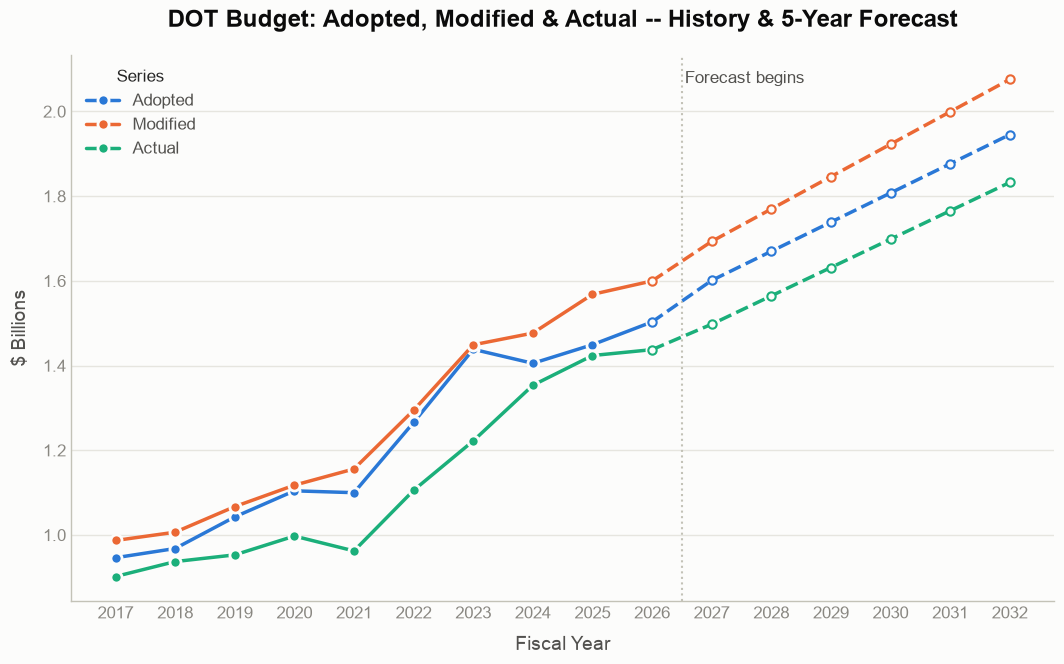

In [13]:
fig2, ax2 = plt.subplots(figsize=(11, 7), facecolor=SURFACE)
ax2.set_facecolor(SURFACE)

for col, color in SERIES.items():
    # Historical: solid + markers
    ax2.plot(
        train_table["fiscal_year"], train_table[col] / 1e9,
        color=color, linewidth=2.5, marker="o", markersize=8,
        markerfacecolor=color, markeredgecolor=SURFACE, markeredgewidth=2,
        label=col.capitalize(), zorder=3,
    )

    # Forecast: dashed, same continuity anchor as Figure 1, no shaded band
    fc = extended_fits[col]["forecast"].set_index("fiscal_year")
    last_hist_value_c = train_table.loc[train_table["fiscal_year"] == last_hist_year, col].iloc[0]
    fx = [last_hist_year] + EXTENDED_YEARS_PLOT
    fy = [last_hist_value_c] + list(fc.loc[EXTENDED_YEARS_PLOT, "point_forecast"])
    ax2.plot(
        fx, np.array(fy) / 1e9,
        color=color, linewidth=2.5, linestyle="--", marker="o", markersize=6,
        markerfacecolor=SURFACE, markeredgecolor=color, markeredgewidth=1.5,
        zorder=3,
    )

# Same forecast divider as Figure 1
ax2.axvline(last_hist_year + 0.5, color=BASELINE, linewidth=1.5, linestyle=":", zorder=2)
ax2.text(
    last_hist_year + 0.55, 0.97, "Forecast begins",
    transform=ax2.get_xaxis_transform(),
    color=INK_SECONDARY, fontsize=12, va="top", ha="left",
)

ax2.set_xlabel("Fiscal Year", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax2.set_ylabel("$ Billions", fontsize=14, color=INK_SECONDARY, labelpad=10)
ax2.set_title(
    "DOT Budget: Adopted, Modified & Actual -- History & 5-Year Forecast",
    fontsize=17, fontweight="bold", color=INK_PRIMARY, pad=20,
)
ax2.set_xticks(list(train_table["fiscal_year"]) + EXTENDED_YEARS_PLOT)
ax2.tick_params(labelsize=12, colors=INK_MUTED)

ax2.grid(axis="y", color=GRIDLINE, linewidth=1, alpha=0.8)
ax2.grid(axis="x", visible=False)
ax2.set_axisbelow(True)
for spine_name in ("top", "right"):
    ax2.spines[spine_name].set_visible(False)
for spine_name in ("left", "bottom"):
    ax2.spines[spine_name].set_color(BASELINE)

ax2.legend(fontsize=12, frameon=False, loc="upper left", labelcolor=INK_SECONDARY, title="Series", title_fontsize=12)

fig2.tight_layout(pad=2)

THREE_CLEAN_PATH = "dot_forecast_three_clean.png"
fig2.savefig(THREE_CLEAN_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved Figure 2 (all three series, no bands) to {THREE_CLEAN_PATH}")
plt.show()


## Cumulative 5-Year Need (Modified, FY2028-2032)

Sum of the FY2028-2032 Modified point forecasts, with a combined low/high
range built by summing the yearly lower and upper bounds. **Caveat, stated
plainly:** summing each year's independent 95% bound this way is a simple,
transparent approximation, not a statistically tight combined interval --
because all five years' forecasts come from the same fitted line, their
errors are correlated (a high FY2028 tends to come with a high FY2029,
etc.), so a rigorous joint interval would likely be narrower than this sum.
Summing the bounds is the conservative, wider direction, which is the safer
side to be wrong on for a planning range.

In [14]:
modified_forecast = extended_fits["modified"]["forecast"].set_index("fiscal_year")
five_year_window = modified_forecast.loc[list(range(2028, 2033))]

cumulative_point = five_year_window["point_forecast"].sum()
cumulative_low = five_year_window["lower_95"].sum()
cumulative_high = five_year_window["upper_95"].sum()

print("FY2028-2032 Modified forecast, year by year:")
print(five_year_window[["point_forecast", "lower_95", "upper_95"]].to_string())
print()
print("Cumulative 5-year projected budget need (Modified, FY2028-2032):")
print(f"  Point estimate : {cumulative_point:>18,.0f}")
print(f"  Low (sum of lower_95)  : {cumulative_low:>18,.0f}")
print(f"  High (sum of upper_95) : {cumulative_high:>18,.0f}")
print(f"  Range width             : {cumulative_high - cumulative_low:>18,.0f}")


FY2028-2032 Modified forecast, year by year:
              point_forecast         lower_95         upper_95
fiscal_year                                                   
2028        1,769,704,643.16 1,635,890,531.16 1,903,518,755.15
2029        1,846,236,752.18 1,705,555,973.57 1,986,917,530.80
2030        1,922,768,861.21 1,774,629,694.24 2,070,908,028.17
2031        1,999,300,970.23 1,843,196,484.33 2,155,405,456.13
2032        2,075,833,079.25 1,911,329,964.80 2,240,336,193.71

Cumulative 5-year projected budget need (Modified, FY2028-2032):
  Point estimate :      9,613,844,306
  Low (sum of lower_95)  :      8,870,602,648
  High (sum of upper_95) :     10,357,085,964
  Range width             :      1,486,483,316


## Limitation: This Is a Scenario, Not a Prediction

A 5-year projection built from 10 annual observations is an **"if current
trends continue" scenario**, not a precise prediction of what FY2028-2032
will actually look like -- stated plainly, not as a hedge:

- **The intervals widen year over year because the uncertainty is real and
  compounding.** Each additional forecast year is extrapolated further from
  the data the model actually saw, and the classic prediction-interval
  formula used throughout this notebook (Step 3) correctly grows the margin
  for that -- by FY2032 the interval is meaningfully wider than FY2027's,
  and that widening is the model being honest about what it doesn't know,
  not a defect to fix.
- **The model has no mechanism for recessions, policy shifts, or
  emergencies.** It is a straight line fit to 10 points of steady historical
  growth. It cannot see a citywide fiscal crisis, a change in how DOT's
  capital program is funded, a new mandate, or an infrastructure emergency
  coming -- any of which could move the actual FY2028-2032 numbers well
  outside even the widest interval shown here.
- **The 5-year cumulative total compounds this further.** It's five
  correlated single-year uncertainties added together, not five independent
  ones -- treat the cumulative low/high above as a wide planning range, not
  a budget figure to commit to.
- **How to use this:** the point forecasts and the cumulative total are a
  reasonable planning anchor for "what does continuing the current trend
  imply." The intervals are the range worth holding flexibility for. Neither
  is a substitute for revisiting the forecast as each actual fiscal year's
  numbers come in.

---
**Stopping here per instructions.** The FY2028-2032 year-by-year forecast
table with 95% prediction intervals, the interval-width growth, the 5-year
cumulative Modified need, and the saved plot are all above.